## Introduction to Scikit-Learn (sklearn)
Covered topics:
1. End to end scikit-learn workflow
2. Getting the data ready
3. Choosing the right estimator/algorithm for the project
4. Fitting the model/algorithm and use it to make predictions on our data
5. Evaluating the model
6. Improving the model
7. Save and load a trained model
8. Putting it all together

# 1. End to end Scikit-Learn workflow

In [1]:
import pandas as pd
import numpy as np
# %matplotlib inline
import matplotlib.pyplot as plt
heart_df = pd.read_csv("../data/heart-disease.csv")
heart_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## b. create the features matrix and the labels series

In [2]:
# b. create the features matrix, X, the data used to predict the label
X = heart_df.drop("target", axis=1)

# create the label, Y, the output/result
y = heart_df["target"]

## c. choosing the right model and hyperparameters

In [3]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)

# we'll keep default parameters
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

## d. Fit the model to the training data

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) # 80 percent of the data will be used for training
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
# make a prediction with the model we just trained
y_preds = clf.predict(X_test)
y_preds

array([1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0])

## e. evaluate the model on the training data and the test data

In [6]:
# type1. using .score() method
clf.score(X_train, y_train), clf.score(X_test, y_test) 

(1.0, 0.8852459016393442)

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [8]:
# type2. using classification_report() function
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.87      0.90      0.89        30
           1       0.90      0.87      0.89        31

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [9]:
# type3. using confusion_matrix() function
confusion_matrix(y_test, y_preds)

array([[27,  3],
       [ 4, 27]])

In [10]:
# type4. using accuracy_score() function
accuracy_score(y_test, y_preds)

0.8852459016393442

## improve the model

In [11]:
# trying different amounts of n_estimators
np.random.seed(42)
for i in range (70, 90, 1):
    print(f"trying model with {i} estimators...")
    clf = RandomForestClassifier(n_estimators = i).fit(X_train, y_train)
    print(f"model accuracy on test set: {clf.score(X_test,y_test)*100:.2f}")
    print()
    # 74

trying model with 70 estimators...
model accuracy on test set: 83.61

trying model with 71 estimators...
model accuracy on test set: 81.97

trying model with 72 estimators...
model accuracy on test set: 86.89

trying model with 73 estimators...
model accuracy on test set: 86.89

trying model with 74 estimators...
model accuracy on test set: 88.52

trying model with 75 estimators...
model accuracy on test set: 85.25

trying model with 76 estimators...
model accuracy on test set: 85.25

trying model with 77 estimators...
model accuracy on test set: 85.25

trying model with 78 estimators...
model accuracy on test set: 90.16

trying model with 79 estimators...
model accuracy on test set: 86.89

trying model with 80 estimators...
model accuracy on test set: 85.25

trying model with 81 estimators...
model accuracy on test set: 86.89

trying model with 82 estimators...
model accuracy on test set: 85.25

trying model with 83 estimators...
model accuracy on test set: 88.52

trying model with 84

## saving the model and loading it

In [12]:
import pickle
pickle.dump(clf, open("randomforest_1.pkl", "wb"))

In [13]:
loaded_model = pickle.load(open("randomforest_1.pkl", "rb"))
loaded_model.score(X_test, y_test)

0.9016393442622951

# 2. Get the data ready

## Getting our data ready to be used with machine learning
1. Splitting the data into features and labels
2. Filling (imputing) or disregarding missing values
3. Converting non-numerical values into numerical values (aka feature encoding)

In [14]:
car_sales = pd.read_csv("../data/car-sales-extended.csv")

In [15]:
# splitting the data into x and y and forming the training and test sets for each

x = car_sales.drop("Price", axis=1)
y = car_sales["Price"]

In [16]:
# building an ML model

np.random.seed(42)
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
            
from sklearn.ensemble import RandomForestRegressor
# model = RandomForestRegressor()
# model.fit(x_train, y_train)
# model.score(x_test, y_test)

# DOESNT WORK BECAUSE THE DATA CONTAINS NON NUMERICAL AND DISCRETE DATA THAT NEEDS TO BE TRANSFORMED INTO NUMERICAL DATAS

### Transforming all the data into numerical form

In [17]:
car_sales = pd.read_csv("../data/car-sales-extended.csv")
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043
...,...,...,...,...,...
995,Toyota,Black,35820,4,32042
996,Nissan,White,155144,3,5716
997,Nissan,Blue,66604,4,31570
998,Honda,White,215883,4,4001


In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make", "Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot", one_hot, categorical_features)], remainder="passthrough")
transformed_x = pd.DataFrame(transformer.fit_transform(x))
transformed_x

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


In [19]:
dummies = pd.get_dummies(car_sales[["Make", "Colour", "Doors"]])
dummies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,False,True,False,False,False,False,False,False,True
1,5,True,False,False,False,False,True,False,False,False
2,4,False,True,False,False,False,False,False,False,True
3,4,False,False,False,True,False,False,False,False,True
4,3,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,4,False,False,False,True,True,False,False,False,False
996,3,False,False,True,False,False,False,False,False,True
997,4,False,False,True,False,False,True,False,False,False
998,4,False,True,False,False,False,False,False,False,True


In [20]:
np.random.seed(42)
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(transformed_x, y, test_size=0.2)
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.3235867221569877

### Handling data sets with missing values
1. Fill them with some value (imputation)
2. Remove the samples that have missing values

In [21]:
car_sales = pd.read_csv("../data/car-sales-extended-missing-data.csv")
x = car_sales.drop("Price", axis=1)
y = car_sales["Price"]
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


In [22]:
car_sales.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [23]:
# option1: do it anyways

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make", "Colour", "Doors"]
oneHot = OneHotEncoder()
transformer = ColumnTransformer([("oneHot", oneHot, categorical_features)], remainder="passthrough")
x_t1 = pd.DataFrame(transformer.fit_transform(x))
x_t1

# RETURNS A CSR MATRIX

,0
0,<Compressed Sparse Row sparse matrix of dtype ...
1,<Compressed Sparse Row sparse matrix of dtype ...
2,<Compressed Sparse Row sparse matrix of dtype ...
3,<Compressed Sparse Row sparse matrix of dtype ...
4,<Compressed Sparse Row sparse matrix of dtype ...
...,...
995,<Compressed Sparse Row sparse matrix of dtype ...
996,<Compressed Sparse Row sparse matrix of dtype ...
997,<Compressed Sparse Row sparse matrix of dtype ...
998,<Compressed Sparse Row sparse matrix of dtype ...


In [24]:
car_sales["Make"] =car_sales["Make"].fillna("missing")
car_sales["Colour"] = car_sales["Colour"].fillna("missing")
car_sales["Odometer (KM)"] = car_sales["Odometer (KM)"].fillna(car_sales["Odometer (KM)"].mean())
car_sales["Doors"] = car_sales["Doors"].fillna(4)
car_sales = car_sales.dropna() 
# car_sales

In [25]:
x = car_sales.drop("Price", axis=1)
y = car_sales["Price"]

# transforming the data into numerical form 

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make", "Colour", "Doors"]
oneHot = OneHotEncoder()
transformer = ColumnTransformer([("oneHot", oneHot, categorical_features)], remainder="passthrough")
x_t2 = transformer.fit_transform(x)
x_t2

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3800 stored elements and shape (950, 15)>

In [26]:
# option2: fill the missing values

car_sales = pd.read_csv("../data/car-sales-extended-missing-data.csv")
car_sales.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [27]:
car_sales = car_sales.dropna(subset="Price")
len(car_sales)

950

In [28]:
x = car_sales.drop("Price", axis=1)
y = car_sales["Price"]

from sklearn.model_selection import train_test_split
np.random.seed(42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [29]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# filling categorical values with missing and numerical values with mean
cat_imputer = SimpleImputer(strategy="constant", fill_value="missing")
door_imputer = SimpleImputer(strategy="constant", fill_value=4)
num_imputer = SimpleImputer(strategy="mean")

#defining columns
cat_features = ["Make", "Colour"]
door_features = ["Doors"]
num_features = ["Odometer (KM)"]

# creating the imputer
imputer = ColumnTransformer([("cat_imputer", cat_imputer, cat_features),
                             ("door_imputer", door_imputer, door_features),
                             ("num_imputer", num_imputer, num_features)])

In [30]:
filled_x_train = pd.DataFrame(imputer.fit_transform(x_train), columns=["Make", "Colour", "Doors", "Odometer (KM)"])
filled_x_test = pd.DataFrame(imputer.fit_transform(x_test), columns=["Make", "Colour", "Doors", "Odometer (KM)"])
filled_x_train

,Make,Colour,Doors,Odometer (KM)
0,Honda,White,4.0,71934.0
1,Toyota,Red,4.0,162665.0
2,Honda,White,4.0,42844.0
3,Honda,White,4.0,195829.0
4,Honda,Blue,4.0,219217.0
...,...,...,...,...
755,Toyota,missing,4.0,218803.0
756,BMW,Blue,5.0,245427.0
757,Toyota,White,4.0,196225.0
758,Honda,Blue,4.0,133117.0


In [31]:
from sklearn.preprocessing import OneHotEncoder 
from sklearn.compose import ColumnTransformer

categorical_features = ["Make", "Colour", "Doors"]
oneHot = OneHotEncoder()
transformer = ColumnTransformer([("oneHot", oneHot, categorical_features)], remainder="passthrough")
x_train_t = transformer.fit_transform(filled_x_train)
x_test_t = transformer.transform(filled_x_test)

In [32]:
np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(x_train_t, y_train)
model.score(x_test_t, y_test)

0.25366332156443805

# 3. Choosing the right estimator/algorithm for our problems

Some things to note: 
* sklearn refers to machine learning models, algorithms as estimators
* Classification problem - predicting a category (heart disease or not)
    * sometime the name `clf` is used for a classifier estimator
* Regression problem - predicting a number (selling price of a car)

## 3.1 Picking a machine learning model for a regression problem
Using the California Housing Dataset from sklearn datasets

In [33]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [34]:
housing_df = pd.DataFrame(housing["data"], columns=housing["feature_names"])
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [35]:
housing_df["MedHouseVal"] = housing["target"]
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [36]:
housing_df= housing_df.rename(columns={"MedHouseVal": "target"}) 

In [37]:
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [38]:
# import algorithm - RIDGE
from sklearn.linear_model import Ridge

# setup random seed
np.random.seed(42)

# creating the data
x = housing_df.drop("target", axis=1)
y = housing_df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# fitting the model to the training data
model = Ridge()
model.fit(x_train, y_train)

# test the model on the test data
model.score(x_test, y_test)

0.5758549611440131

In [39]:
# import algorithm - RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

# setup random seed
np.random.seed(42)

# creating the data
x = housing_df.drop("target", axis=1)
y = housing_df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# fitting the model to the training data
model = RandomForestRegressor()
model.fit(x_train, y_train)

# test the model on the test data
model.score(x_test, y_test)

0.806652667101436

In [40]:
# import algorithm - HistGradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

# setup random seed
np.random.seed(42)

# creating the data
x = housing_df.drop("target", axis=1)
y = housing_df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# fitting the model to the training data
model = HistGradientBoostingRegressor(max_iter=100).fit(x_train, y_train)

# test the model on the test data
model.score(x_test, y_test)


0.834709142444373

In [41]:
# import algorithm - LASSO
from sklearn import linear_model

# setup random seed
np.random.seed(42)

# creating the data
x = housing_df.drop("target", axis=1)
y = housing_df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# fitting the model to the training data
model = linear_model.Lasso(alpha=0.1)
model.fit(x_train, y_train)

# test the model on the test data
model.score(x_test, y_test)

0.5318167610318159

In [42]:
# import algorithm - SVM (linear kernel)
from sklearn import svm

# setup random seed
np.random.seed(42)

# creating the data
x = housing_df.drop("target", axis=1)
y = housing_df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# fitting the model to the training data
# model = svm.SVR(kernel="linear")
# model.fit(x_train, y_train)

# test the model on the test data
# model.score(x_test, y_test)

In [43]:
# import algorithm - SVM (RBF kernel)
from sklearn import svm

# setup random seed
np.random.seed(42)

# creating the data
x = housing_df.drop("target", axis=1)
y = housing_df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# fitting the model to the training data
# model = svm.SVR(kernel="rbf")
# model.fit(x_train, y_train)

# test the model on the test data
model.score(x_test, y_test)

0.5318167610318159

## 3.2 Picking a machine learning model for a classification problem


In [44]:
heart_df = pd.read_csv("../data/heart-disease.csv")
heart_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [45]:
# importing algorithm - linear SVC 
from sklearn.svm import LinearSVC

np.random.seed(42)

x = heart_df.drop("target", axis=1)
y = heart_df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# clf = LinearSVC(max_iter=1000)
# clf.fit(x_train, y_train)

clf.score(x_test, y_test)

0.9836065573770492

In [46]:
# importing algorithm - RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

x = heart_df.drop("target", axis=1)
y = heart_df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

clf = RandomForestClassifier(n_estimators=100)
clf.fit(x_train, y_train)

clf.score(x_test, y_test)

0.8524590163934426

# 4. Fitting the model to the data to make predictions


## 4.1 Fitting the model into the data

In [47]:
# importing algorithm - RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

x = heart_df.drop("target", axis=1)
y = heart_df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

clf = RandomForestClassifier(n_estimators=100)
clf.fit(x_train, y_train)

clf.score(x_test, y_test)

0.8524590163934426

## 4.2 Making predictions using a machine learning model
There are two ways of making predictions:
1. using `predict()` - returns predicted labels
2. using `predict_proba()` - returns the probabilities of the returned labels

### 4.2.1 using `predict()`

In [48]:
clf.predict(x_test)

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [49]:
np.array(y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [50]:
# comparing predictions to the truth labels to evaluate the model
from sklearn.metrics import accuracy_score
y_preds = clf.predict(x_test)
np.mean(y_preds == y_test), clf.score(x_test, y_test), accuracy_score(y_preds, y_test)

(np.float64(0.8524590163934426), 0.8524590163934426, 0.8524590163934426)

### 4.2.2 `using predict_proba()`

In [51]:
clf.predict_proba(x_test)

array([[0.89, 0.11],
       [0.49, 0.51],
       [0.43, 0.57],
       [0.84, 0.16],
       [0.18, 0.82],
       [0.14, 0.86],
       [0.36, 0.64],
       [0.95, 0.05],
       [0.99, 0.01],
       [0.47, 0.53],
       [0.26, 0.74],
       [0.7 , 0.3 ],
       [0.11, 0.89],
       [0.95, 0.05],
       [0.03, 0.97],
       [0.02, 0.98],
       [0.01, 0.99],
       [0.84, 0.16],
       [0.95, 0.05],
       [0.98, 0.02],
       [0.51, 0.49],
       [0.89, 0.11],
       [0.38, 0.62],
       [0.29, 0.71],
       [0.26, 0.74],
       [0.34, 0.66],
       [0.2 , 0.8 ],
       [0.22, 0.78],
       [0.83, 0.17],
       [0.15, 0.85],
       [0.94, 0.06],
       [0.92, 0.08],
       [0.96, 0.04],
       [0.62, 0.38],
       [0.46, 0.54],
       [0.89, 0.11],
       [0.44, 0.56],
       [0.16, 0.84],
       [0.33, 0.67],
       [0.08, 0.92],
       [0.13, 0.87],
       [0.17, 0.83],
       [0.18, 0.82],
       [0.38, 0.62],
       [0.32, 0.68],
       [0.77, 0.23],
       [0.39, 0.61],
       [0.  ,

## Making predictions on a regression model using `predict()`

In [52]:
from sklearn.ensemble import RandomForestRegressor

# setup random seed
np.random.seed(42)

# creating the data
x = housing_df.drop("target", axis=1)
y = housing_df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# fitting the model to the training data
model = RandomForestRegressor(n_estimators=100)
model.fit(x_train, y_train)

y_preds = model.predict(x_test)

In [53]:
y_preds

array([0.4939   , 0.75494  , 4.9285964, ..., 4.8363785, 0.71782  ,
       1.67781  ], shape=(4128,))

In [54]:
np.array(y_test)

array([0.477  , 0.458  , 5.00001, ..., 5.00001, 0.723  , 1.515  ],
      shape=(4128,))

In [55]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_preds)

0.32656738464147306

# 5. Evaluating a Machine Learning Model 
There are three ways to evaluate an sklearn estimator
1. Using the estimator's built in `.score()` method
2. Using the statistical methods
3. Using the `scoring` parameter

## 5.1 Evaluating using the `.score()` method

In [56]:
# importing algorithm - RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

x = heart_df.drop("target", axis=1)
y = heart_df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

clf = RandomForestClassifier(n_estimators=100)
clf.fit(x_train, y_train)

clf.score(x_test, y_test)

0.8524590163934426

In [57]:
from sklearn.ensemble import RandomForestRegressor

# setup random seed
np.random.seed(42)

# creating the data
x = housing_df.drop("target", axis=1)
y = housing_df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# fitting the model to the training data
model = RandomForestRegressor(n_estimators=100)
model.fit(x_train, y_train)

model.score(x_test, y_test)

0.806652667101436

## 5.2 Using the statistical methods

In [58]:
from sklearn.model_selection import cross_val_score

# importing algorithm - RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

x = heart_df.drop("target", axis=1)
y = heart_df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

clf = RandomForestClassifier(n_estimators=100)
clf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [59]:
clf.score(x_test, y_test)

0.8524590163934426

In [60]:
cross_val_score(clf, x, y, scoring=None)

array([0.81967213, 0.86885246, 0.81967213, 0.78333333, 0.76666667])

In [61]:
np.random.seed(42)

# single training and test split score 
clf_score = clf.score(x_test, y_test)

# taking the mean of the five fold cross validation score
clf_cv_score = np.mean(cross_val_score(clf, x, y, cv=5))

# comparing the two
clf_score, clf_cv_score

(0.8524590163934426, np.float64(0.8248087431693989))

### 5.2.1 Classification model evaluation metrics
1. Accuracy
2. Area under ROC curve
3. Confusion matrix
4. Classification report

**Accuracy**

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

heart_df = pd.read_csv("../data/heart-disease.csv")

x = heart_df.drop("target", axis=1)
y = heart_df["target"]

clf = RandomForestClassifier(n_estimators=100)

cvScore = np.mean(cross_val_score(clf, x, y, cv=5))
cvScore

np.float64(0.8018032786885245)

**Area under Receiver Operating Characteristic (ROC) curve**

* Area under curve (AUC)
* ROC curve

ROC curves are a comparison for the model's true positive rate versus (tpr) false positive rate (fpr).

* True positive = model predicts 1 and truth is 1
* False positive = mdoel predicts 1 and truth is 0
* True negative = model predicts 0 and truth is 0
* False negative = model predicts 0 and truth is 1

In [63]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [64]:
from sklearn.metrics import roc_curve

clf = RandomForestClassifier(n_estimators=100)
clf.fit(x_train, y_train)

y_probs = clf.predict_proba(x_test)
y_probs_positive = y_probs[:, 1]

In [65]:
fpr, tpr, threshold = roc_curve(y_test, y_probs_positive)

In [66]:
# creating a function for plotting ROC curves

import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):
    """
    Plots a ROC curve given the fpr and tpr of a model.
    """

    # plot roc curve
    fig, ax = plt.subplots()
    ax.plot(fpr, tpr, color="orange", label="ROC")
    #plot line with no predictive power
    ax.plot([0,1], [0,1], color="darkblue", linestyle="--", label="Guessing")

    #customizing the plot
    ax.set(xlabel="False Positive Rate (FPR)", ylabel="True Positive Rate (TPR)")
    ax.legend()
    fig.suptitle("ROC Curve")
    
    
    
    

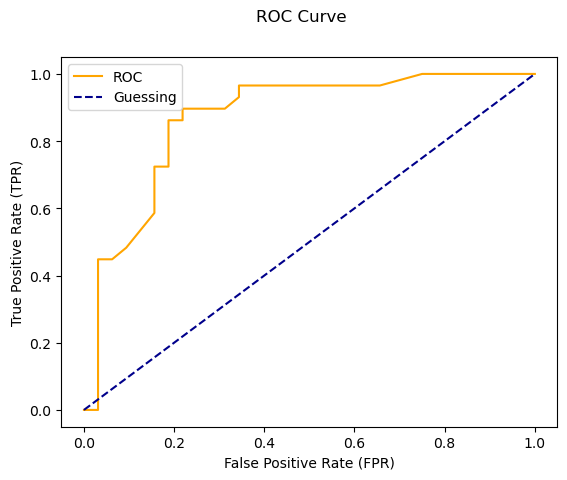

In [67]:
plot_roc_curve(fpr, tpr)

In [68]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_probs_positive)

0.8679956896551724

**Confusion Matrix** 
* A quick way of comparing the y_preds and y_test, therefore giving us an idea of where the model is getting confused

In [69]:
from sklearn.metrics import confusion_matrix
y_preds = clf.predict(x_test)
confusion_matrix(y_test, y_preds)

array([[24,  8],
       [ 3, 26]])

In [70]:
pd.crosstab(y_test, y_preds, rownames=["Actual Label"], colnames=["Predicted Labels"])

Predicted Labels,0,1
Actual Label,,
0,24,8
1,3,26


In [71]:
# how to install a package into the current conda environment from jupyter notebook
!conda install --yes --prefix {sys.prefix} seaborn

Jupyter detected...
3 channel Terms of Service accepted



EnvironmentLocationNotFound: Not a conda environment: C:\Users\USER\OneDrive\Desktop\MachineLearning\Projects\sample_project\SciKit-Learn\{sys.prefix}



<Axes: >

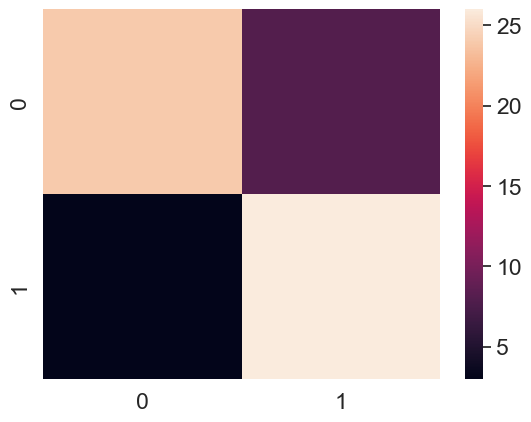

In [72]:
# making the confusion matrix more visible 
import seaborn as sns

sns.set(font_scale=1.5)
conf_mat = confusion_matrix(y_test, y_preds)
sns.heatmap(conf_mat)

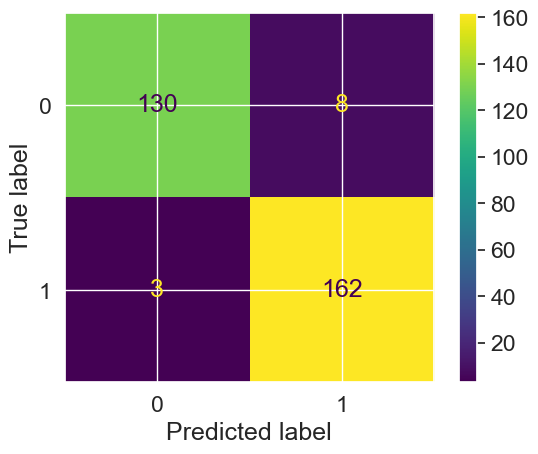

In [73]:
# making confusion matrix using sklearn
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(estimator=clf, X=x, y=y)

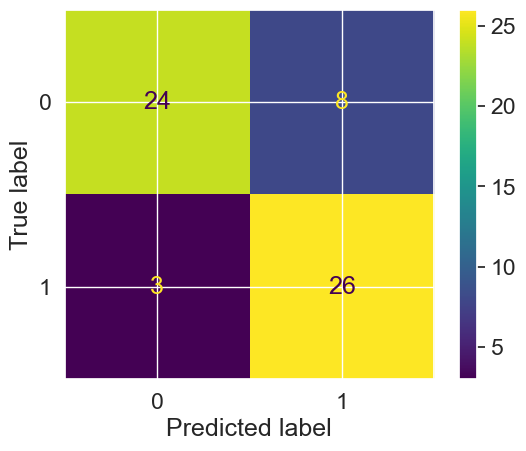

In [74]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_preds)

**Classification Report**

In [75]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.89      0.75      0.81        32
           1       0.76      0.90      0.83        29

    accuracy                           0.82        61
   macro avg       0.83      0.82      0.82        61
weighted avg       0.83      0.82      0.82        61



* **precision**- proportion of correct positive predictions
* **recall**- true positive rate
* **f1-score**-combination of precision and recall
* **support**- number of samples each metric was calculated on
* **accuracy**- proportion of correct predictions
* **macro-avg**- avg precision, recall and f1-score between the 0 and 1 class, doesnt take class imbalance into account
* **weighted-avg**- macro-avg but also takes class imbalance into account, difference between the macro-avg and weighted-avg takes place when there is significant imbalance between the classes

### 5.2.2 Regression Model Evaluation Metrics

Read more on all the available metrics at - https://scikit-learn.org/stable/modules/model_evaluation.html#regression_metrics

The ones covered are:
1. R^2 or coefficient of determination
2. Mean absolute errror (MAE)
3. Mean squared error (MSE)

**R^2 or coefficient of determination**

In [76]:
from sklearn.ensemble import RandomForestRegressor

# setup random seed
np.random.seed(42)

# creating the data
x = housing_df.drop("target", axis=1)
y = housing_df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# fitting the model to the training data
model = RandomForestRegressor(n_estimators=100)
model.fit(x_train, y_train)

model.score(x_test, y_test)

0.806652667101436

**Mean absolute error (MAE)-**
MAE is the average of the absolute differences between the predicted values and actual values.

In [77]:
from sklearn.metrics import mean_absolute_error
y_preds = model.predict(x_test)
mae = mean_absolute_error(y_test, y_preds)
mae

0.32656738464147306

**Mean squared error (MSE)-**
MSE is the average of the square of the absolute differences between the predicted values and actual values. The square amplifies larger differences

In [78]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_preds)
mse

0.25336408094921037

In [79]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_preds)
rmse

0.5033528394170538

## 5.3 Using the `scoring` parameter

### 5.3.1 For classification problems

In [80]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

np.random.seed(42)
heart_df = pd.read_csv("../data/heart-disease.csv")

x = heart_df.drop("target", axis=1)
y = heart_df["target"]

clf = RandomForestClassifier(n_estimators=100)

In [81]:
np.random.seed(42)
cv_acc = cross_val_score(clf, x, y, cv=5, scoring=None )
cv_acc

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

In [82]:
cvScore = np.mean(cross_val_score(clf, x, y, cv=5, scoring=None )) # using scoring=None uses the default scoring method
cvScore

np.float64(0.8018032786885245)

In [83]:
np.random.seed(42)
cv_acc = np.mean(cross_val_score(clf, x, y, cv=5, scoring="accuracy" ))
cv_acc

np.float64(0.8248087431693989)

In [84]:
np.random.seed(42)
cv_precision = np.mean(cross_val_score(clf, x, y, cv=5, scoring="precision" ))
cv_precision

np.float64(0.8329547346025924)

In [85]:
np.random.seed(42)
cv_recall = np.mean(cross_val_score(clf, x, y, cv=5, scoring="recall" ))
cv_recall

np.float64(0.8545454545454545)

In [86]:
np.random.seed(42)
cv_f1 = np.mean(cross_val_score(clf, x, y, cv=5, scoring="f1" ))
cv_f1

np.float64(0.8426854603423344)

### 5.3.2 For Regression Problems

In [87]:
from sklearn.ensemble import RandomForestRegressor

# setup random seed
np.random.seed(42)

# creating the data
x = housing_df.drop("target", axis=1)
y = housing_df["target"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# fitting the model to the training data
model = RandomForestRegressor(n_estimators=100)
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [88]:
from sklearn.model_selection import cross_val_score
cv_r2 = cross_val_score(model, x, y, cv=3, scoring=None)
cv_r2

array([0.62451992, 0.72452692, 0.61839499])

In [89]:
cv_mae = cross_val_score(model, x, y, cv=3, scoring="neg_mean_absolute_error")
cv_mae

array([-0.51528071, -0.42365253, -0.50463115])

In [90]:
cv_mse = cross_val_score(model, x, y, cv=3, scoring="neg_mean_squared_error")
cv_mse

array([-0.51264463, -0.33177472, -0.53838716])

# 6. Improving a Model

First prediction - baseline prediction
First model - baseline model

From a data perspective, for a better model, we need:
* More data
* More information from a single 

From a model perspective, for a better model, we need:
* A better model could be used
* The model could be improved by tuning the hyperparameters

**Parameters:** Model finds parameters within the date

**Hyperparameters:** Settings on a model that we can adjust to potentially improve the results

There are three ways to adjust hyperparameters
1. by hand
2. randomly by RandomSearchCV
3. Exhaustively by GridSearchCV

In [91]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()
clf.get_params() # shows the hyperparameters available for the given model

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

## 6.1 Tuning Hyperparameters by Hand

3 sets: training, validation and test sets

In [92]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

We are going to adjust the following hyperparameters
1. `max_depth`
2. `max_features`
3. `min_samples_leaf`
4. `min_samples_split`
5. `n_estimators`

In [93]:
def evaluate_preds(y_true, y_preds):
    """
    Performs evaluation comparison on y_true vs y_pred labels on a classification model
    """
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(y_true, y_preds)
    precision = precision_score(y_true, y_preds)
    recall = recall_score(y_true, y_preds)
    f1 = f1_score(y_true, y_preds)
    metric_dict = {"accuracy": round(accuracy, 2),
                   "precision": round(precision, 2),
                   "recall": round(recall, 2),
                   "f1": round(f1, 2),
                  }
    print(f"Accuracy: {accuracy:.2f}%\n"
          f"Precision: {accuracy:.2f}\n"
          f"Recall: {recall:.2f}\n"
          f"F1 Score: {f1:.2f}")

    return metric_dict

In [94]:
from sklearn.ensemble import RandomForestClassifier



# shuffling the data
heart_dfs = heart_df.sample(frac=1)

# split into x and y
x = heart_dfs.drop("target", axis=1)
y = heart_dfs["target"]

train_split = round(0.7 * len(heart_dfs))
valid_split = round(train_split + 0.15 * len(heart_dfs))
x_train, y_train = x[:train_split], y[:train_split]  # x and y data upto the respective train splits
x_valid, y_valid = x[train_split:valid_split], y[train_split:valid_split]  # x and y data from the respective train splits to the valid splits
x_test, y_test = x[valid_split:], y[valid_split:]   # x and y data from the valid splits onwards

In [95]:
np.random.seed(42)
clf = RandomForestClassifier(n_estimators=100)
clf.fit(x_train, y_train)
y_preds = clf.predict(x_valid) # making baseline predictions
baseline_metrics = evaluate_preds(y_valid, y_preds)
baseline_metrics

Accuracy: 0.87%
Precision: 0.87
Recall: 0.86
F1 Score: 0.89


{'accuracy': 0.87, 'precision': 0.92, 'recall': 0.86, 'f1': 0.89}

In [96]:
np.random.seed(42)
clf_1 = RandomForestClassifier(n_estimators=100)
clf_1.fit(x_train, y_train)
y_preds = clf_1.predict(x_valid) # making baseline predictions
baseline_metrics = evaluate_preds(y_valid, y_preds)
baseline_metrics

Accuracy: 0.87%
Precision: 0.87
Recall: 0.86
F1 Score: 0.89


{'accuracy': 0.87, 'precision': 0.92, 'recall': 0.86, 'f1': 0.89}

In [97]:
np.random.seed(42)
clf_2 = RandomForestClassifier(n_estimators=100, max_depth=10)
clf_2.fit(x_train, y_train)
y_preds = clf_2.predict(x_valid) # making baseline predictions
baseline_metrics = evaluate_preds(y_valid, y_preds)
baseline_metrics

Accuracy: 0.87%
Precision: 0.87
Recall: 0.86
F1 Score: 0.89


{'accuracy': 0.87, 'precision': 0.92, 'recall': 0.86, 'f1': 0.89}

In [98]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

## 6.2 Tuning Hyperparameters using RandomizedSearchCV

In [99]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split

grid = {"n_estimators": [10, 100, 200, 500, 1000, 1200],
        "max_depth": [None, 5, 10, 20, 30],
        "max_features": ["auto", "sqrt"],
        "min_samples_split": [2, 4, 6],
        "min_samples_leaf": [1, 2, 4]}

np.random.seed(42)

x = heart_dfs.drop("target", axis=1)
y = heart_dfs["target"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

clf = RandomForestClassifier(n_jobs=1) # n_jobs dictate how much of the computer processor will be dedicated 
rs_clf = RandomizedSearchCV(estimator=clf,
                            param_distributions=grid,
                            n_iter=10,
                            cv=5,
                            verbose=2)
rs_clf.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.8s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.9s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.9s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.9s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.8s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100

C:\Users\USER\OneDrive\Desktop\MachineLearning\Projects\sample_project\env\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\USER\OneDrive\Desktop\MachineLearning\Projects\sample_project\env\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\USER\OneDrive\Desktop\MachineLearning\Projects\sample_project\env\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._vali

,estimator,RandomForestC...fier(n_jobs=1)
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [100]:
rs_clf.best_params_

{'n_estimators': 500,
 'min_samples_split': 6,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

In [101]:
# making predictions using these best hyperparameters

rs_y_preds = rs_clf.predict(x_test)
rs_metrics = evaluate_preds(y_test, rs_y_preds)
rs_metrics

Accuracy: 0.85%
Precision: 0.85
Recall: 0.90
F1 Score: 0.89


{'accuracy': 0.85, 'precision': 0.88, 'recall': 0.9, 'f1': 0.89}

## 6.3 Tuning Hyperparameters using GridSearchCV

In [102]:
from sklearn.model_selection import GridSearchCV

grid_2 = {"n_estimators": [1000, 800],
        "max_depth": [20, 10],
        "max_features": ["auto", "sqrt"],
        "min_samples_split": [2, 4],
        "min_samples_leaf": [1, 2]}

np.random.seed(42)

x = heart_dfs.drop("target", axis=1)
y = heart_dfs["target"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

clf = RandomForestClassifier(n_jobs=1) # n_jobs dictate how much of the computer processor will be dedicated 
gs_clf = RandomizedSearchCV(estimator=clf,
                            param_distributions=grid,
                            cv=5,
                            verbose=2)
gs_clf.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.9s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.9s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.8s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.9s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.9s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100

C:\Users\USER\OneDrive\Desktop\MachineLearning\Projects\sample_project\env\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\USER\OneDrive\Desktop\MachineLearning\Projects\sample_project\env\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\USER\OneDrive\Desktop\MachineLearning\Projects\sample_project\env\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._vali

,estimator,RandomForestC...fier(n_jobs=1)
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [103]:
gs_clf.best_params_

{'n_estimators': 500,
 'min_samples_split': 6,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

In [104]:
gs_y_preds = gs_clf.predict(x_test)
gs_metrics = evaluate_preds(y_test, gs_y_preds)

Accuracy: 0.85%
Precision: 0.85
Recall: 0.90
F1 Score: 0.89


<Axes: >

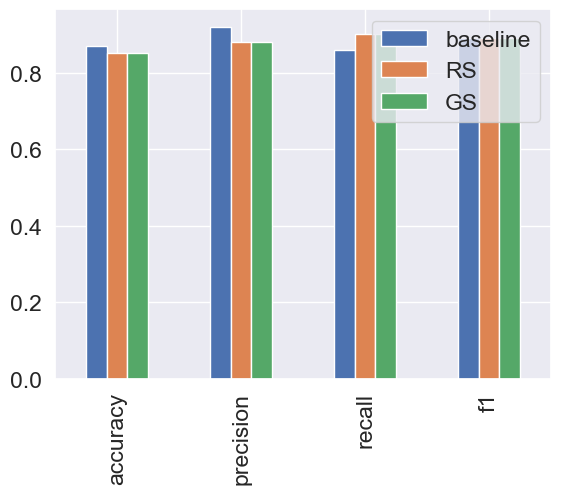

In [105]:
metrics_comparison = pd.DataFrame({"baseline": baseline_metrics,
                                   "RS": rs_metrics,
                                   "GS": gs_metrics})
metrics_comparison.plot.bar()

# 7. Saving and Loading a Model

**Using Pickle**

In [106]:
import pickle
pickle.dump(gs_clf, open("gs_randomforest_model_1.pkl", "wb"))

In [107]:
loaded_model = pickle.load(open("gs_randomforest_model_1.pkl", "rb"))

In [108]:
pickle_y_preds = loaded_model.predict(x_test)
evaluate_preds(y_test, pickle_y_preds)

Accuracy: 0.85%
Precision: 0.85
Recall: 0.90
F1 Score: 0.89


{'accuracy': 0.85, 'precision': 0.88, 'recall': 0.9, 'f1': 0.89}

**Using Joblib**

In [109]:
from joblib import dump, load

dump(gs_clf, filename="gs_randomforest_model_1.joblib")

['gs_randomforest_model_1.joblib']

In [110]:
loaded_joblib_model = load("gs_randomforest_model_1.joblib")

In [111]:
joblib_y_preds = loaded_model.predict(x_test)
evaluate_preds(y_test, joblib_y_preds)

Accuracy: 0.85%
Precision: 0.85
Recall: 0.90
F1 Score: 0.89


{'accuracy': 0.85, 'precision': 0.88, 'recall': 0.9, 'f1': 0.89}

# 8. Putting it all together

In [112]:
data = pd.read_csv("../data/car-sales-extended-missing-data.csv")
data

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


Steps we want to do (all in one cell):
1. fill missing data
2. convert the data to numbers
3. build a model on the data

In [113]:
# getting the data ready
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# importing the model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV

# setting up random seed
np.random.seed(42)
import numpy as np

# importing the data and dropping rows with missing labels
data = pd.read_csv("../data/car-sales-extended-missing-data.csv")
data = data.dropna(subset=["Price"])

# define different features and transformer pipeline
categorical_features = ["Make", "Colour"]
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
                                           ("onehot", OneHotEncoder(handle_unknown="ignore"))])

door_feature = ["Doors"]
door_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="constant", fill_value=4))])

numeric_feature = ["Odometer (KM)"]
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="mean"))])

# setting up preprocessing steps
preprocessor = ColumnTransformer(transformers=[("cat", categorical_transformer, categorical_features), 
                                               ("door", door_transformer, door_feature),
                                               ("num", numeric_transformer, numeric_feature)])

# creating a preprocessing and modelling pipeline
model = Pipeline(steps=[("preprocessor", preprocessor),
                        ("model", RandomForestRegressor())])

# splitting the data
x = data.drop("Price", axis=1)
y = data["Price"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# fitting the model
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.22188417408787875

In [2]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# set random seed
np.random.seed(42)

# importing the data and dropping rows with missing labels
data = pd.read_csv("../data/car-sales-extended-missing-data.csv")
data = data.dropna(subset=["Price"])

# define different features and transformer pipelines
categorical_features = ["Make", "Colour"]
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

door_feature = ["Doors"]
door_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=4))
])

numeric_feature = ["Odometer (KM)"]
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

# setting up preprocessing steps
preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_transformer, categorical_features), 
    ("door", door_transformer, door_feature),
    ("num", numeric_transformer, numeric_feature)
])

# creating a preprocessing and modelling pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

# splitting the data
x = data.drop("Price", axis=1)
y = data["Price"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# fitting the model
model.fit(x_train, y_train)
score = model.score(x_test, y_test)
print(score)


0.22188417408787875


In [16]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

data = pd.read_csv("../data/car-sales-extended-missing-data.csv")
data = data.dropna(subset=["Price"])

x = data.drop("Price", axis=1)
y = data["Price"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

cat_features = ["Make", "Colour"]
door_feature = ["Doors"]
num_feature = ["Odometer (KM)"]

cat_transformer = Pipeline(steps=[("cat_fill", SimpleImputer(strategy="constant", fill_value="missing")),
                                  ("onehot", OneHotEncoder(handle_unknown="ignore"))])
door_transformer = Pipeline(steps=[("door_fill", SimpleImputer(strategy="constant", fill_value=4))])
num_transformer = Pipeline(steps=[("num_fill", SimpleImputer(strategy="mean"))])

preprocessor = ColumnTransformer(transformers=[("cat-transform", cat_transformer, cat_features), 
                                              ("door-transform", door_transformer, door_feature),
                                              ("num-transform", num_transformer, num_feature)])

model = Pipeline(steps=[("preprocessor", preprocessor),
                               ("model", RandomForestRegressor(n_estimators=100))])

model.fit(x_train, y_train)
model.score(x_test, y_test)                        

0.22188417408787875

In [18]:
model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat-transform', ...), ('door-transform', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
from sklearn.model_selection import GridSearchCV
pipeGrid = {"preprocessor__num-transform__num_fill__strategy":["mean", "median"],
            "model__n_estimators":[100, 300, 500, 1000, 1200],
            "model__max_depth":[5, 10, 20, 30],
            "model__min_samples_split": [2, 4, 6, 10],
            "model__min_samples_leaf": [1, 3]}
gs_model = GridSearchCV(model, pipeGrid, cv=5, verbose=2)
gs_model.fit(x_train, y_train)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits
[CV] END model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100, preprocessor__num-transform__num_fill__strategy=mean; total time=   0.0s
[CV] END model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100, preprocessor__num-transform__num_fill__strategy=mean; total time=   0.0s
[CV] END model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100, preprocessor__num-transform__num_fill__strategy=mean; total time=   0.0s
[CV] END model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100, preprocessor__num-transform__num_fill__strategy=mean; total time=   0.0s
[CV] END model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100, preprocessor__num-transform__num_fill__strategy=mean; total time=   0.0s
[CV] END model__max_depth=

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 3], 'model__min_samples_split': [2, 4, ...], 'model__n_estimators': [100, 300, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat-transform', ...), ('door-transform', ...), ...]"


In [21]:
gs_model.best_params_

{'model__max_depth': 5,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 6,
 'model__n_estimators': 100,
 'preprocessor__num-transform__num_fill__strategy': 'mean'}

In [22]:
gs_model.score(x_test, y_test)

0.33439930745170043